<a href="https://colab.research.google.com/github/tanmayrathi/ML_PROJECT_TAE1/blob/main/ML_Models_Performance_70%3A30_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Model performance analysis For 70:30 Split
1.Logistic Regression
2.K-Nearest Neighbors (KNN)
3.Decision Tree
4.Random Forest
5.Support Vector Machine (SVM)
6.Naive Bayes
7.Gradient Boosting
8.AdaBoost
9.Extra Trees
10.XGBoost
11.Linear Discriminant Analysis 12.Quadratic Discriminant Analysis






In [3]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve

# The 12 Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier

In [4]:
# --- STEP 1: MOUNT GOOGLE DRIVE ---
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# --- STEP 2: LOAD DATASET ---
file_path = '/content/drive/MyDrive/ML_datasets/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(file_path)

In [6]:
# --- STEP 3: EXPLORATORY DATA ANALYSIS (EDA) ---
print("### Dataset Info ###")
print(df.info())

print("\n### Missing Values ###")
print(df.isnull().sum())

print(df.head())



### Dataset Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

### Missing Values ###
id                     0
gender                 0
age                    0
hypertension           0
heart_d

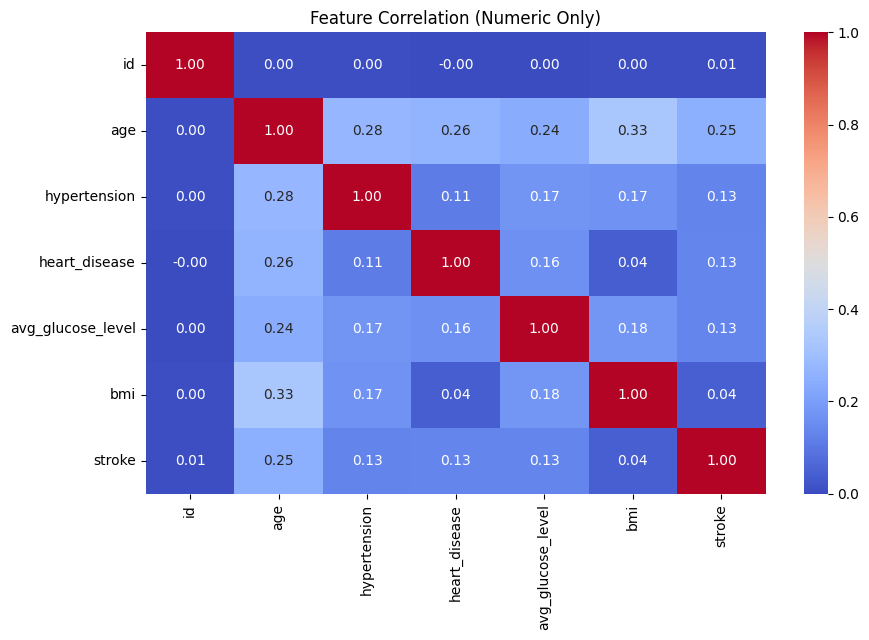

In [7]:
# Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation (Numeric Only)')
plt.show()

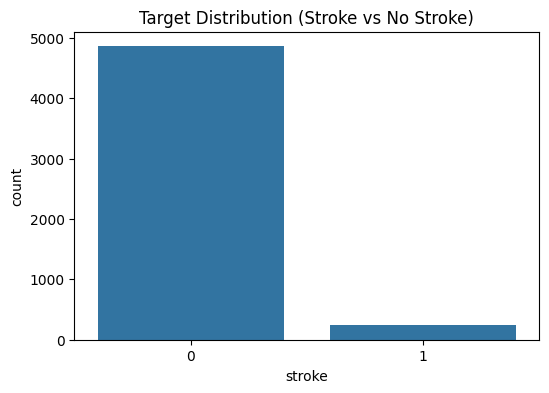

In [8]:
# Distribution of Target
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df)
plt.title('Target Distribution (Stroke vs No Stroke)')
plt.show()

In [9]:
# --- STEP 4: DATA PREPROCESSING ---
# 1. Drop the ID column (not a predictor)
df = df.drop('id', axis=1)

# 2. Handle Missing Values (BMI)
# The dataset often has 'N/A' or NaN. SimpleImputer fills these with the mean.
imputer = SimpleImputer(strategy='mean')
df['bmi'] = imputer.fit_transform(df[['bmi']])

# 3. Clean Categorical Data
# Remove 'Other' from gender if it exists (usually only 1 instance)
df = df[df['gender'] != 'Other']

# 4. Encoding Categorical Data
# We use Label Encoding for simplicity across all 12 models
le = LabelEncoder()
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [10]:
# --- STEP 5: TRAIN-TEST SPLIT (70:30) ---
X = df.drop('stroke', axis=1)
y = df['stroke']

# Standardize features (Crucial for KNN, SVM, and Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fixed split applied to ALL models
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

In [11]:
# --- STEP 6: DEFINE THE 12 MODELS ---
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True), # probability=True required for AUC
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis()
}


### Evaluating 12 Models... ###

Finished: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Finished: K-Nearest Neighbors
Finished: Decision Tree
Finished: Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Finished: Support Vector Machine
Finished: Naive Bayes
Finished: Gradient Boosting


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Finished: AdaBoost
Finished: Extra Trees


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Finished: XGBoost
Finished: Linear Discriminant Analysis
Finished: Quadratic Discriminant Analysis


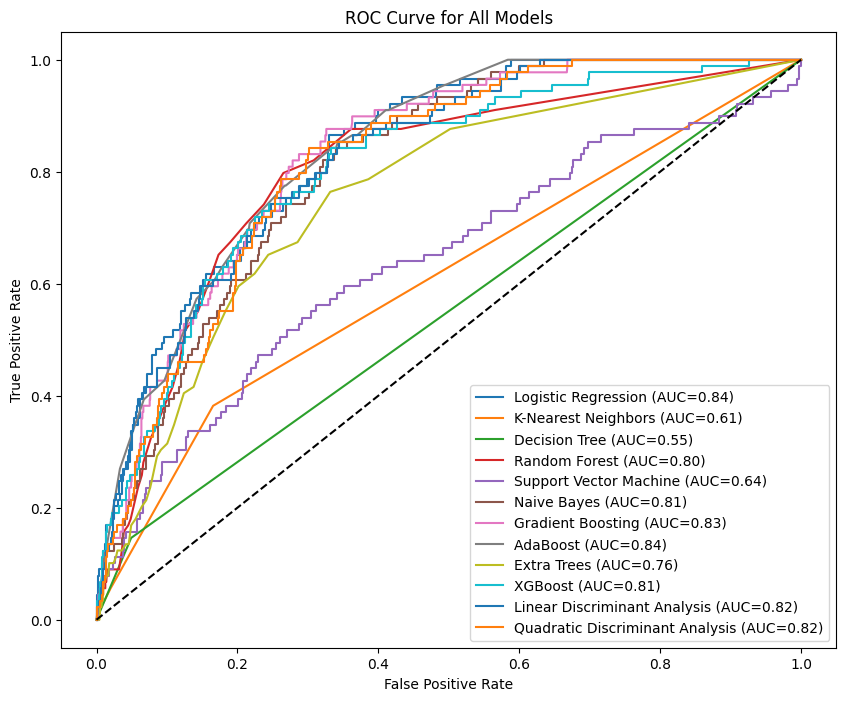

In [12]:
# --- STEP 7: RUN MODELS AND EVALUATE ---
results_list = []

plt.figure(figsize=(10,8))  # For ROC curves

print("\n### Evaluating 12 Models... ###\n")

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC Score": auc,
        "CV Mean Accuracy": cv_mean
    })

    print(f"Finished: {name}")

# Plot ROC Curve
plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for All Models")
plt.legend()
plt.show()


### FINAL MODEL COMPARISON ###
                              Model  Accuracy  Precision    Recall  F1 Score  \
7                          AdaBoost  0.941944   0.000000  0.000000  0.000000   
0               Logistic Regression  0.941944   0.000000  0.000000  0.000000   
6                 Gradient Boosting  0.941944   0.500000  0.044944  0.082474   
10     Linear Discriminant Analysis  0.938030   0.333333  0.067416  0.112150   
11  Quadratic Discriminant Analysis  0.870841   0.205405  0.426966  0.277372   
5                       Naive Bayes  0.856491   0.177340  0.404494  0.246575   
9                           XGBoost  0.939987   0.421053  0.089888  0.148148   
3                     Random Forest  0.941292   0.000000  0.000000  0.000000   
8                       Extra Trees  0.936725   0.166667  0.022472  0.039604   
4            Support Vector Machine  0.941944   0.000000  0.000000  0.000000   
1               K-Nearest Neighbors  0.940639   0.250000  0.011236  0.021505   
2       

/tmp/ipykernel_3490/2397858193.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC Score', y='Model', data=results_df, palette='magma')


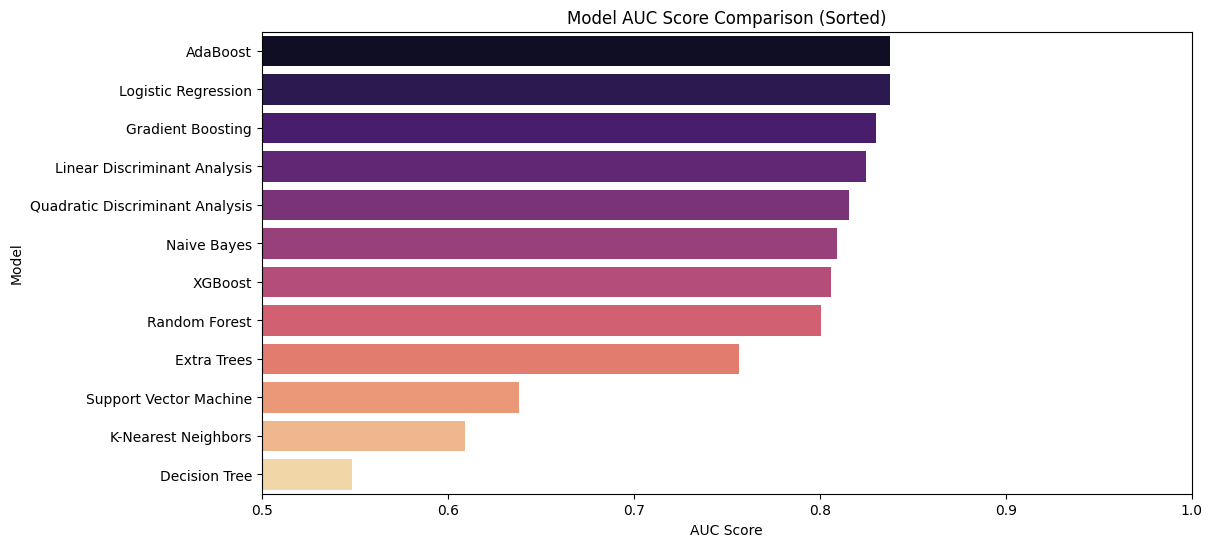

In [13]:
# --- STEP 8: FINAL RESULTS DISPLAY ---
results_df = pd.DataFrame(results_list).sort_values(by='AUC Score', ascending=False)

print("\n### FINAL MODEL COMPARISON ###")
print(results_df)

# Visualizing Comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='AUC Score', y='Model', data=results_df, palette='magma')
plt.title('Model AUC Score Comparison (Sorted)')
plt.xlim(0.5, 1.0) # Zoom in to see differences
plt.show()

In [17]:
# Create results list
results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Some models (like SVM without probability=True) may fail here
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred  # fallback

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append([name, acc, auc, prec, rec, f1])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarn

In [29]:
# Highlight best model
def highlight_best(row):
    return ['background-color: blue' if row.name == results_df["F1 Score"].idxmax() else '' for _ in row]

results_df.style.apply(highlight_best, axis=1)

,Model,Accuracy,Precision,Recall,F1 Score,AUC Score,CV Mean Accuracy
7,AdaBoost,0.941944,0.000000,0.000000,0.000000,0.837981,0.955257
0,Logistic Regression,0.941944,0.000000,0.000000,0.000000,0.837662,0.955257
6,Gradient Boosting,0.941944,0.500000,0.044944,0.082474,0.830294,0.951621
10,Linear Discriminant Analysis,0.938030,0.333333,0.067416,0.112150,0.824893,0.947426
11,Quadratic Discriminant Analysis,0.870841,0.205405,0.426966,0.277372,0.815579,0.879469
5,Naive Bayes,0.856491,0.177340,0.404494,0.246575,0.809354,0.872759
9,XGBoost,0.939987,0.421053,0.089888,0.148148,0.806312,0.946589
3,Random Forest,0.941292,0.000000,0.000000,0.000000,0.800885,0.955537
8,Extra Trees,0.936725,0.166667,0.022472,0.039604,0.756540,0.951342
4,Support Vector Machine,0.941944,0.000000,0.000000,0.000000,0.638473,0.955257


In [23]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("🏆 Best Model:")
print("Model Name:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("AUC:", best_model["AUC Score"])   # FIXED
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])

🏆 Best Model:
Model Name: Quadratic Discriminant Analysis
Accuracy: 0.8708414872798435
AUC: 0.8155793831118304
Precision: 0.20540540540540542
Recall: 0.42696629213483145
F1 Score: 0.2773722627737226


In [24]:
# ---------------- CROSS VALIDATION ----------------
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cv_results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        pipeline = make_pipeline(StandardScaler(), model)
        scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    cv_results.append([name, scores.mean(), scores.std()])

    print(f"\n{name}")
    print("Mean Accuracy:", scores.mean())
    print("Std Dev:", scores.std())


Logistic Regression
Mean Accuracy: 0.9510669291263122
Std Dev: 0.0006041007882929026

K-Nearest Neighbors
Mean Accuracy: 0.9418671690967184
Std Dev: 0.0021110227640427355

Decision Tree
Mean Accuracy: 0.9095725575056879
Std Dev: 0.008753128652138936

Random Forest
Mean Accuracy: 0.9495011797267174
Std Dev: 0.0013160531114655687

Support Vector Machine
Mean Accuracy: 0.9512626238425549
Std Dev: 0.00037260580644051796

Naive Bayes
Mean Accuracy: 0.866317891787147
Std Dev: 0.009852129661643783

Gradient Boosting
Mean Accuracy: 0.9485225144758506
Std Dev: 0.0014540889635394922

AdaBoost
Mean Accuracy: 0.9512626238425549
Std Dev: 0.00037260580644051796

Extra Trees
Mean Accuracy: 0.9459775248164284
Std Dev: 0.0029964357972178243


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:15:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:15:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:15:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:15:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


XGBoost
Mean Accuracy: 0.9418664024181045
Std Dev: 0.004667633496921159

Linear Discriminant Analysis
Mean Accuracy: 0.9442172307185119
Std Dev: 0.004900239924010666

Quadratic Discriminant Analysis
Mean Accuracy: 0.8796264741792227
Std Dev: 0.00979842729805236


In [25]:
# Convert CV results to DataFrame
cv_df = pd.DataFrame(cv_results, columns=["Model", "Mean Accuracy", "Std Dev"])

# Sort CV results
cv_df = cv_df.sort_values(by="Mean Accuracy", ascending=False).reset_index(drop=True)

cv_df

,Model,Mean Accuracy,Std Dev
0,AdaBoost,0.951263,0.000373
1,Support Vector Machine,0.951263,0.000373
2,Logistic Regression,0.951067,0.000604
3,Random Forest,0.949501,0.001316
4,Gradient Boosting,0.948523,0.001454
5,Extra Trees,0.945978,0.002996
6,Linear Discriminant Analysis,0.944217,0.004900
7,K-Nearest Neighbors,0.941867,0.002111
8,XGBoost,0.941866,0.004668
9,Decision Tree,0.909573,0.008753


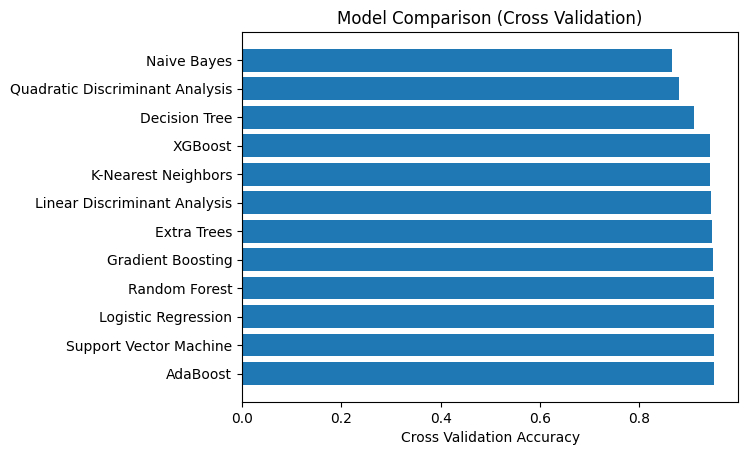

In [27]:
# ---------------- PLOTTING ----------------
import matplotlib.pyplot as plt

# Cross Validation Graph
plt.figure()
plt.barh(cv_df["Model"], cv_df["Mean Accuracy"])
plt.xlabel("Cross Validation Accuracy")
plt.title("Model Comparison (Cross Validation)")
plt.show()



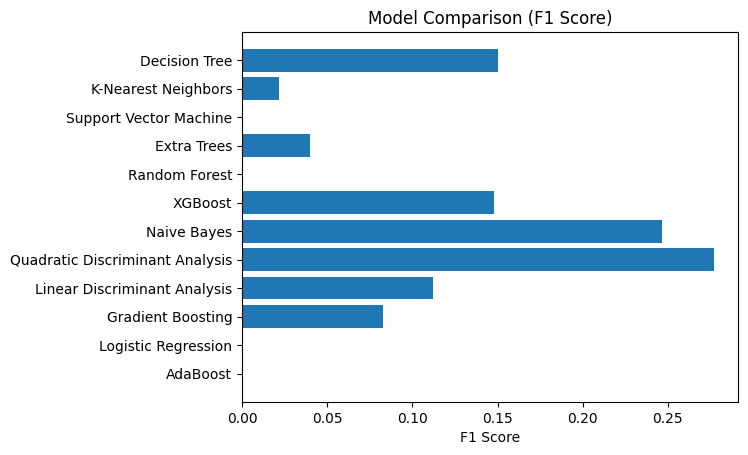

In [28]:
# F1 Score Graph
plt.figure()
plt.barh(results_df["Model"], results_df["F1 Score"])
plt.xlabel("F1 Score")
plt.title("Model Comparison (F1 Score)")
plt.show()